In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reload data
df = pd.read_csv('C:/Users/Kingsley/splendor-trial-analysis/ Data/DA task.csv')

# Fix dates
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], errors='coerce')
df['CONVERTED_AT'] = pd.to_datetime(df['CONVERTED_AT'], errors='coerce')
df['TRIAL_START'] = pd.to_datetime(df['TRIAL_START'], errors='coerce')
df['TRIAL_END'] = pd.to_datetime(df['TRIAL_END'], errors='coerce')

# Deduplicate
df = df.drop_duplicates()

# Org level summary
org_df = df.drop_duplicates('ORGANIZATION_ID')[
    ['ORGANIZATION_ID','CONVERTED','CONVERTED_AT','TRIAL_START','TRIAL_END']
].copy()

# Time to convert (in days)
org_df['days_to_convert'] = (
    org_df['CONVERTED_AT'] - org_df['TRIAL_START']
).dt.days

print("Dataset reloaded successfully!")
print(f"Total orgs: {org_df['ORGANIZATION_ID'].nunique()}")
print(f"Converted orgs: {org_df['CONVERTED'].sum()}")
print(f"\nAverage days to convert: {org_df['days_to_convert'].mean():.1f}")
print(f"Median days to convert: {org_df['days_to_convert'].median():.1f}")

C:\Users\Kingsley\AppData\Local\Temp\ipykernel_16260\774744851.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], errors='coerce')
C:\Users\Kingsley\AppData\Local\Temp\ipykernel_16260\774744851.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CONVERTED_AT'] = pd.to_datetime(df['CONVERTED_AT'], errors='coerce')
C:\Users\Kingsley\AppData\Local\Temp\ipykernel_16260\774744851.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TRIAL_START'] = pd.to_datetime(df['TRIAL_START'], errors='coerce')
C:\Users\Kingsley\App

Dataset reloaded successfully!
Total orgs: 966
Converted orgs: 206

Average days to convert: -0.1
Median days to convert: 0.0


In [16]:
# Investigate conversion timing
converted_orgs = org_df[org_df['CONVERTED'] == True].copy()

print("Sample of converted orgs:")
print(converted_orgs[['ORGANIZATION_ID','TRIAL_START',
                        'CONVERTED_AT','days_to_convert']].head(10))

print(f"\nDays to convert distribution:")
print(converted_orgs['days_to_convert'].describe())

print(f"\nHow many have null CONVERTED_AT: {converted_orgs['CONVERTED_AT'].isnull().sum()}")
print(f"How many have 0 days: {(converted_orgs['days_to_convert']==0).sum()}")
print(f"How many have negative days: {(converted_orgs['days_to_convert']<0).sum()}")
print(f"How many have positive days: {(converted_orgs['days_to_convert']>0).sum()}")

Sample of converted orgs:
                        ORGANIZATION_ID         TRIAL_START CONVERTED_AT  \
2784   014f83e0deae3ac42041a126f1022974                 NaT          NaT   
3075   015f38565a692a85e2824e94926a12ef                 NaT          NaT   
5403   01842569c6942b80bce161f32bbfd53d                 NaT          NaT   
5686   01f72f7e769498606ab1cc67d4869793                 NaT          NaT   
6301   0230aaa200a6c33b10c198297beb8478                 NaT          NaT   
7100   024847dac7c181bcb49c774b053ef892                 NaT          NaT   
7193   03129b37388dfb824491fb54aec77553                 NaT          NaT   
10030  03f5b05fccdf685c1040367c49a93151                 NaT          NaT   
11141  04c356f5c28a5be4e1dea4065437393e 2026-03-22 15:39:00          NaT   
11145  04e2e1509ccf0a2bdaf1a965610037b1                 NaT          NaT   

       days_to_convert  
2784               NaN  
3075               NaN  
5403               NaN  
5686               NaN  
6301        

In [18]:
# ── PRODUCT METRICS WE CAN CALCULATE ─────────────────────

print("=" * 55)
print("SPLENDOR ANALYTICS — PRODUCT METRICS REPORT")
print("=" * 55)

# ── METRIC 1: Overall Conversion Rate ─────────────────────
total_orgs = org_df['ORGANIZATION_ID'].nunique()
converted = org_df['CONVERTED'].sum()
not_converted = total_orgs - converted
conversion_rate = converted / total_orgs * 100

print(f"""
METRIC 1: CONVERSION RATE
━━━━━━━━━━━━━━━━━━━━━━━━━
Total organisations:     {total_orgs}
Converted:               {converted}
Not converted:           {not_converted}
Conversion rate:         {conversion_rate:.1f}%
""")

# ── METRIC 2: Feature Adoption Rates ──────────────────────
# Build org matrix
org_activities = df.groupby(
    ['ORGANIZATION_ID','ACTIVITY_NAME','CONVERTED']
).size().reset_index(name='count')

org_matrix = org_activities.pivot_table(
    index=['ORGANIZATION_ID','CONVERTED'],
    columns='ACTIVITY_NAME',
    values='count',
    fill_value=0
).reset_index()

activity_cols = [col for col in org_matrix.columns
                 if col not in ['ORGANIZATION_ID','CONVERTED']]

print("METRIC 2: FEATURE ADOPTION RATES")
print("━" * 40)
adoption = {}
for act in activity_cols:
    rate = (org_matrix[act] > 0).mean() * 100
    adoption[act] = round(rate, 1)

adoption_df = pd.DataFrame({
    'Activity': adoption.keys(),
    'Adoption Rate (%)': adoption.values()
}).sort_values('Adoption Rate (%)', ascending=False)

print(adoption_df.to_string(index=False))

SPLENDOR ANALYTICS — PRODUCT METRICS REPORT

METRIC 1: CONVERSION RATE
━━━━━━━━━━━━━━━━━━━━━━━━━
Total organisations:     966
Converted:               206
Not converted:           760
Conversion rate:         21.3%

METRIC 2: FEATURE ADOPTION RATES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                              Activity  Adoption Rate (%)
              Scheduling.Shift.Created               87.8
                Mobile.Schedule.Loaded               47.2
    Scheduling.Shift.AssignmentChanged               35.5
                  PunchClock.PunchedIn               21.8
             Scheduling.Shift.Approved               20.7
         Communication.Message.Created               15.0
Scheduling.Template.ApplyModal.Applied               11.2
           Scheduling.Availability.Set                6.1
              ShiftDetails.View.Opened                4.7
   Scheduling.OpenShiftRequest.Created                4.5
               Absence.Request.Created                4.0
              

In [20]:
# ── METRIC 3: Activation Metrics ──────────────────────────
final_goals = {
    'Goal 1: Shift Created (3+)':
        (org_matrix['Scheduling.Shift.Created'] >= 3),
    'Goal 2: Shift Approved (1+)':
        (org_matrix['Scheduling.Shift.Approved'] >= 1),
    'Goal 3: Template Applied (1+)':
        (org_matrix['Scheduling.Template.ApplyModal.Applied'] >= 1),
    'Goal 4: Open Shift Request (1+)':
        (org_matrix['Scheduling.OpenShiftRequest.Created'] >= 1),
    'Goal 5: Punched In (1+)':
        (org_matrix['PunchClock.PunchedIn'] >= 1),
}

goals_df = pd.DataFrame({
    'ORGANIZATION_ID': org_matrix['ORGANIZATION_ID'],
    'CONVERTED': org_matrix['CONVERTED']
})

for goal, condition in final_goals.items():
    goals_df[goal] = condition.astype(int)

goal_cols = list(final_goals.keys())
goals_df['goals_completed'] = goals_df[goal_cols].sum(axis=1)
goals_df['is_activated'] = (goals_df['goals_completed'] == 5).astype(int)

activated = goals_df['is_activated'] == 1
not_activated = goals_df['is_activated'] == 0
conv = goals_df['CONVERTED']

activation_rate = goals_df['is_activated'].mean() * 100
conv_if_activated = (activated & conv).sum() / activated.sum() * 100
conv_if_not_activated = (not_activated & conv).sum() / not_activated.sum() * 100
lift = conv_if_activated / conv_if_not_activated

print(f"""
METRIC 3: TRIAL ACTIVATION
━━━━━━━━━━━━━━━━━━━━━━━━━━
Total activated orgs:           {activated.sum()}
Activation rate:                {activation_rate:.1f}%
Conversion rate if activated:   {conv_if_activated:.1f}%
Conversion rate if not:         {conv_if_not_activated:.1f}%
Activation lift:                {lift:.2f}x
""")

# ── METRIC 4: Module Adoption ─────────────────────────────
print("METRIC 4: MODULE ADOPTION")
print("━" * 40)

modules = {
    'Scheduling': ['Scheduling.Shift.Created',
                   'Scheduling.Shift.Approved',
                   'Scheduling.Shift.AssignmentChanged',
                   'Scheduling.Template.ApplyModal.Applied',
                   'Scheduling.OpenShiftRequest.Created'],
    'Mobile':     ['Mobile.Schedule.Loaded'],
    'Punch Clock':['PunchClock.PunchedIn',
                   'PunchClock.PunchedOut'],
    'Absence':    ['Absence.Request.Created',
                   'Absence.Request.Approved',
                   'Absence.Request.Rejected'],
    'Communication': ['Communication.Message.Created'],
    'Timesheets': ['Timesheets.BulkApprove.Confirmed'],
    'Integration':['Integration.Xero.PayrollExport.Synced'],
}

for module, activities in modules.items():
    available = [a for a in activities if a in org_matrix.columns]
    used = (org_matrix[available] > 0).any(axis=1)
    rate = used.mean() * 100
    print(f"  {module:<20} {rate:.1f}% of orgs")

# ── METRIC 5: Engagement Segments ─────────────────────────
print(f"""
METRIC 5: ENGAGEMENT SEGMENTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
No Engagement  (0 goals): {(goals_df['goals_completed']==0).sum()} orgs ({(goals_df['goals_completed']==0).mean()*100:.1f}%)
Minimal        (1 goal):  {(goals_df['goals_completed']==1).sum()} orgs ({(goals_df['goals_completed']==1).mean()*100:.1f}%)
Partial        (2-3 goals):{((goals_df['goals_completed']>=2) & (goals_df['goals_completed']<=3)).sum()} orgs ({((goals_df['goals_completed']>=2) & (goals_df['goals_completed']<=3)).mean()*100:.1f}%)
Advanced       (4 goals): {(goals_df['goals_completed']==4).sum()} orgs ({(goals_df['goals_completed']==4).mean()*100:.1f}%)
Fully Activated(5 goals): {(goals_df['goals_completed']==5).sum()} orgs ({(goals_df['goals_completed']==5).mean()*100:.1f}%)
""")


METRIC 3: TRIAL ACTIVATION
━━━━━━━━━━━━━━━━━━━━━━━━━━
Total activated orgs:           12
Activation rate:                1.2%
Conversion rate if activated:   33.3%
Conversion rate if not:         21.2%
Activation lift:                1.57x

METRIC 4: MODULE ADOPTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Scheduling           87.8% of orgs
  Mobile               47.2% of orgs
  Punch Clock          21.8% of orgs
  Absence              4.1% of orgs
  Communication        15.0% of orgs
  Timesheets           1.0% of orgs
  Integration          0.6% of orgs

METRIC 5: ENGAGEMENT SEGMENTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
No Engagement  (0 goals): 491 orgs (50.8%)
Minimal        (1 goal):  216 orgs (22.4%)
Partial        (2-3 goals):204 orgs (21.1%)
Advanced       (4 goals): 43 orgs (4.5%)
Fully Activated(5 goals): 12 orgs (1.2%)



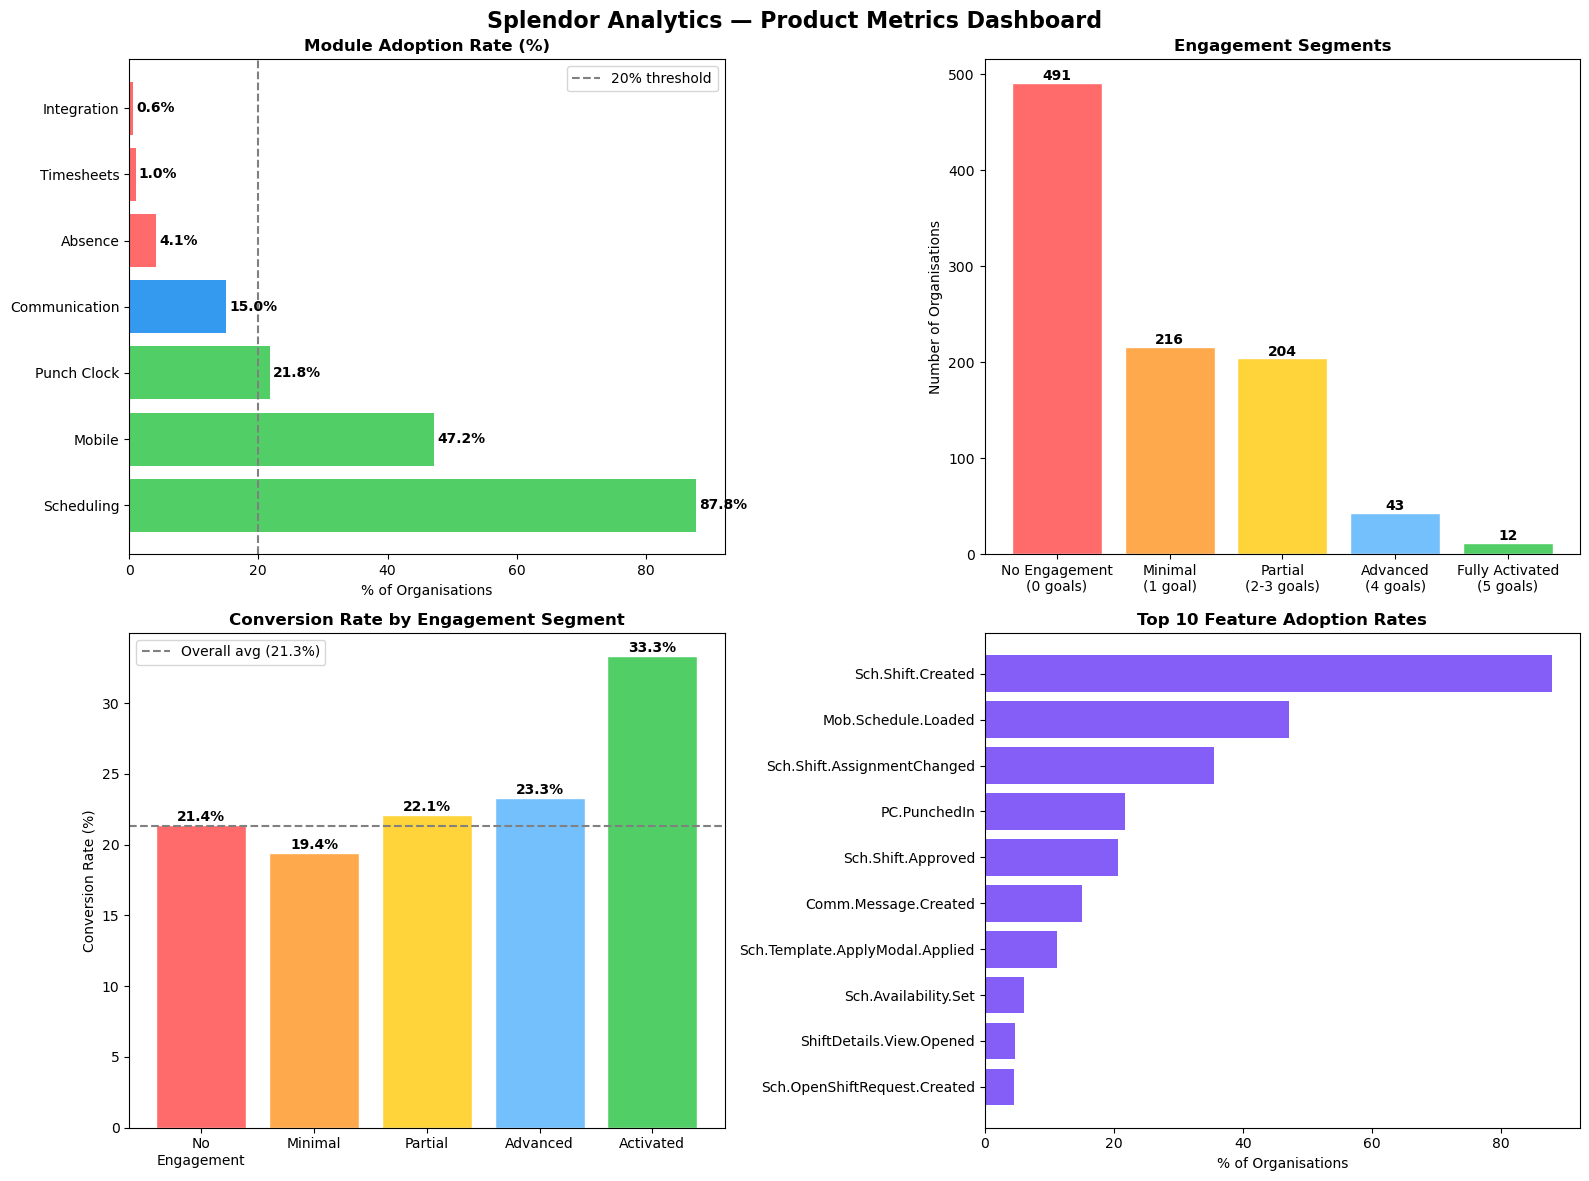

Dashboard saved!


In [22]:
# ── FINAL CHARTS ──────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Splendor Analytics — Product Metrics Dashboard', 
             fontsize=16, fontweight='bold')

# Chart 1 - Module Adoption
module_names = ['Scheduling', 'Mobile', 'Punch Clock', 
                'Communication', 'Absence', 'Timesheets', 'Integration']
module_rates = [87.8, 47.2, 21.8, 15.0, 4.1, 1.0, 0.6]
colors_mod = ['#51cf66' if r > 20 else '#339af0' 
              if r > 5 else '#ff6b6b' for r in module_rates]

bars = axes[0,0].barh(module_names, module_rates, color=colors_mod)
axes[0,0].set_title('Module Adoption Rate (%)', fontweight='bold')
axes[0,0].set_xlabel('% of Organisations')
axes[0,0].axvline(x=20, color='gray', linestyle='--', 
                  label='20% threshold')
axes[0,0].legend()
for bar, val in zip(bars, module_rates):
    axes[0,0].text(bar.get_width() + 0.5, 
                   bar.get_y() + bar.get_height()/2,
                   f'{val}%', va='center', fontweight='bold')

# Chart 2 - Engagement Segments
segments = ['No Engagement\n(0 goals)', 'Minimal\n(1 goal)', 
            'Partial\n(2-3 goals)', 'Advanced\n(4 goals)', 
            'Fully Activated\n(5 goals)']
seg_counts = [491, 216, 204, 43, 12]
seg_colors = ['#ff6b6b', '#ffa94d', '#ffd43b', '#74c0fc', '#51cf66']

bars = axes[0,1].bar(segments, seg_counts, color=seg_colors, 
                     edgecolor='white')
axes[0,1].set_title('Engagement Segments', fontweight='bold')
axes[0,1].set_ylabel('Number of Organisations')
for bar, val in zip(bars, seg_counts):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 3,
                   str(val), ha='center', fontweight='bold')

# Chart 3 - Conversion rate by segment
seg_labels = ['No\nEngagement', 'Minimal', 'Partial', 
              'Advanced', 'Activated']

# Calculate conversion rate per segment
seg_conv_rates = []
masks = [
    goals_df['goals_completed'] == 0,
    goals_df['goals_completed'] == 1,
    (goals_df['goals_completed'] >= 2) & (goals_df['goals_completed'] <= 3),
    goals_df['goals_completed'] == 4,
    goals_df['goals_completed'] == 5
]
for mask in masks:
    rate = goals_df.loc[mask, 'CONVERTED'].mean() * 100
    seg_conv_rates.append(round(rate, 1))

bars = axes[1,0].bar(seg_labels, seg_conv_rates, 
                     color=seg_colors, edgecolor='white')
axes[1,0].set_title('Conversion Rate by Engagement Segment', 
                    fontweight='bold')
axes[1,0].set_ylabel('Conversion Rate (%)')
axes[1,0].axhline(y=21.3, color='gray', linestyle='--',
                  label='Overall avg (21.3%)')
axes[1,0].legend()
for bar, val in zip(bars, seg_conv_rates):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   f'{val}%', ha='center', fontweight='bold')

# Chart 4 - Top 10 feature adoption
top10 = adoption_df.head(10)
axes[1,1].barh(top10['Activity'].str.replace('Scheduling.','Sch.')
               .str.replace('Mobile.','Mob.')
               .str.replace('PunchClock.','PC.')
               .str.replace('Communication.','Comm.'),
               top10['Adoption Rate (%)'],
               color='#845ef7')
axes[1,1].set_title('Top 10 Feature Adoption Rates', fontweight='bold')
axes[1,1].set_xlabel('% of Organisations')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('product_metrics_dashboard.png', dpi=150, 
            bbox_inches='tight')
plt.show()
print("Dashboard saved!")

In [24]:
# ── ACTIONABLE RECOMMENDATIONS ────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════════╗
║         SPLENDOR ANALYTICS — RECOMMENDATIONS TO PRODUCT TEAM     ║
╚══════════════════════════════════════════════════════════════════╝

KEY FINDINGS SUMMARY
━━━━━━━━━━━━━━━━━━━
- Overall conversion rate: 21.3% (1 in 5 orgs)
- 50.8% of orgs show ZERO goal completion — they barely use the product
- Activated orgs convert at 33.3% vs 21.2% for non-activated (1.57x lift)
- Scheduling dominates at 87.8% adoption — it's the core module
- Mobile (47.2%) and Punch Clock (21.8%) are secondary modules
- Timesheets (1.0%) and Integration (0.6%) are severely underused

RECOMMENDATION 1: Fix The Onboarding Drop-off
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Problem:  491 orgs (50.8%) complete ZERO trial goals
Action:   Build a guided onboarding checklist in the product
          that walks new orgs through creating their first 3 shifts
Impact:   Even moving 20% of zero-engagement orgs to 1+ goals
          could significantly improve conversion

RECOMMENDATION 2: Push Mobile Adoption Earlier
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Problem:  Only 47.2% of orgs use mobile despite it being
          the #2 most used feature
Action:   Send mobile app download prompt on Day 1 of trial
          with a specific use case (view your team schedule)
Impact:   Mobile usage shows strong engagement signal

RECOMMENDATION 3: Drive Punch Clock Adoption
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Problem:  Only 21.8% of orgs use Punch Clock
          despite it being a core multi-module feature
Action:   After org creates 3+ shifts, trigger an in-app
          prompt to try the Punch Clock feature
Impact:   Multi-module users show higher conversion intent

RECOMMENDATION 4: Investigate Data Quality
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Problem:  55.4% of event timestamps are null
          140 of 206 converted orgs missing CONVERTED_AT
Action:   Fix event tracking pipeline immediately
          These gaps are hiding the true conversion signal
Impact:   Better data = better activation model in future

RECOMMENDATION 5: Focus On Advanced Segment
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Problem:  43 orgs completed 4/5 goals but did not activate
Action:   Identify these orgs in real time and trigger
          a targeted intervention (call, email, in-app nudge)
          to push them to complete the final goal
Impact:   These are the warmest leads — highest ROI to target

HONEST CAVEAT
━━━━━━━━━━━━━
The behavioural differences between converters and non-converters
are small in this dataset. Conversion may also be influenced by
factors outside the product (sales outreach, pricing, company size).
These goals should be treated as hypotheses to be validated with
an A/B test or cohort analysis as data quality improves.
""")


╔══════════════════════════════════════════════════════════════════╗
║         SPLENDOR ANALYTICS — RECOMMENDATIONS TO PRODUCT TEAM     ║
╚══════════════════════════════════════════════════════════════════╝

KEY FINDINGS SUMMARY
━━━━━━━━━━━━━━━━━━━
- Overall conversion rate: 21.3% (1 in 5 orgs)
- 50.8% of orgs show ZERO goal completion — they barely use the product
- Activated orgs convert at 33.3% vs 21.2% for non-activated (1.57x lift)
- Scheduling dominates at 87.8% adoption — it's the core module
- Mobile (47.2%) and Punch Clock (21.8%) are secondary modules
- Timesheets (1.0%) and Integration (0.6%) are severely underused

RECOMMENDATION 1: Fix The Onboarding Drop-off
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Problem:  491 orgs (50.8%) complete ZERO trial goals
Action:   Build a guided onboarding checklist in the product
          that walks new orgs through creating their first 3 shifts
Impact:   Even moving 20% of zero-engagement orgs to 1+ goals
          could significant